In [1]:
from config import client
import pandas as pd

In [2]:
batch_number_out_query = """
SELECT * FROM zoho_books_analytics.batch_number_out
"""

result = client.query(batch_number_out_query)

batch_number_out_df = pd.DataFrame(result.result_rows, columns=[col for col in result.column_names])

In [3]:
batch_number_out_df.columns

Index(['batch_out_id', 'batch_in_id', 'warehouse_id', 'product_id',
       'quantity_out', 'entity_type', 'invoice_id', 'invoice_item_id',
       'vendor_credit_id', 'vendor_credits_item_id', 'inventory_adjustment_id',
       'inventory_adjustment_item_id', 'bundle_id', 'bundle_item_id',
       'created_time', 'last_modified_time', 'package_id', 'package_item_id'],
      dtype='object')

In [4]:
batch_number_out_df.describe()

,batch_out_id,batch_in_id,warehouse_id,product_id,quantity_out,entity_type,invoice_id,invoice_item_id,vendor_credit_id,vendor_credits_item_id,inventory_adjustment_id,inventory_adjustment_item_id,bundle_id,bundle_item_id,created_time,last_modified_time,package_id,package_item_id
count,110859,110859,110859,110859,110859,110859,110859,110859,110859,110859,110859,110859,110859,110859,110859,110859,110859,110859
unique,110838,39767,74,1898,3687,4,44533,91071,587,1174,2649,4823,1,1,NaN,NaN,1,1
top,1410873000128205027,1410873000117369710,1410873000048741070,1410873000000669376,1920.00,invoice,,,,,,,,,NaN,NaN,,
freq,2,76,15999,3638,3657,102418,8441,8441,109677,109677,103600,103600,110859,110859,NaN,NaN,110859,110859
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023-05-19 23:30:59.674036480+00:00,2023-05-20 10:50:49.680450048+00:00,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018-08-05 02:32:51+00:00,2018-08-05 02:32:51+00:00,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021-11-18 14:28:29+00:00,2021-11-18 16:42:58.500000+00:00,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-01-17 17:34:12+00:00,2024-01-18 16:40:28+00:00,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-01-17 13:23:28+00:00,2025-01-17 15:23:48+00:00,NaN,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-09-24 04:53:22+00:00,2025-09-24 04:53:22+00:00,NaN,NaN


In [5]:
batch_number_out_df['quantity_out'].describe()

count      110859
unique       3687
top       1920.00
freq         3657
Name: quantity_out, dtype: object

In [6]:
batch_number_out_df[batch_number_out_df['quantity_out'] > 44000]

TypeError: '>' not supported between instances of 'str' and 'int'

In [7]:
# convert to float
batch_number_out_df['quantity_out'] = batch_number_out_df['quantity_out'].astype(float)

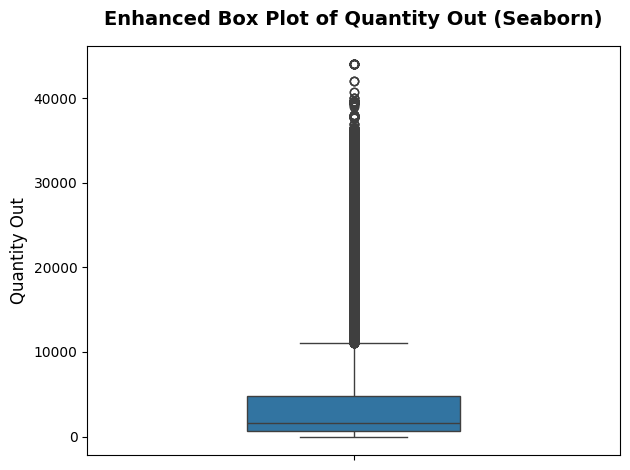

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
# Drop NaN values for plotting
plot_data = batch_number_out_df['quantity_out'].dropna()

sns.boxplot(y=plot_data, width=0.4)
plt.title('Enhanced Box Plot of Quantity Out (Seaborn)', fontsize=14, weight='bold', pad=15)
plt.ylabel('Quantity Out', fontsize=12)

# Adjust layout to prevent clipping
plt.tight_layout()

# Show the plot
plt.show()

In [9]:
batch_number_out_df['entity_type'].value_counts()

entity_type
invoice                             102418
inventory_adjustment_by_quantity      5484
transfer_order                        1775
vendor_credit                         1182
Name: count, dtype: int64

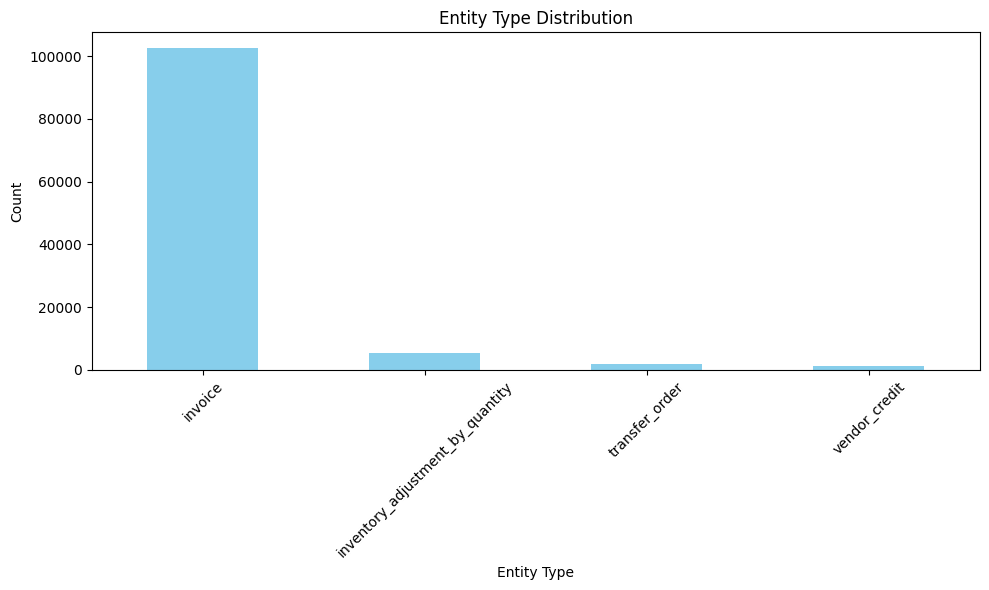

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

counts = batch_number_out_df['entity_type'].value_counts()

# Create bar graph
plt.figure(figsize=(10, 6))
counts.plot(kind='bar', color='skyblue')
plt.title('Entity Type Distribution')
plt.xlabel('Entity Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()